### Simple Parallel Workflow without using LLMs

In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    strike_rate: float
    bpb : float
    boundary_percentage: float
    summary: str



In [25]:
def summary(state: BatsmanState):
    
    summary = f"""
    Strike Rate: {state['strike_rate']}
    Balls/Boundary: {state['bpb']}
    Boundary Percentage: {state['boundary_percentage']}
    """
    state['summary'] = summary

    return state

In [26]:
graph = StateGraph(BatsmanState)

# nodes

graph.add_node('calculate_strike_rate', lambda state: {'strike_rate': (state['runs'] / state['balls']) * 100})
graph.add_node('calculate_bpb', lambda state: {'bpb': (state['balls'] / state['fours'] + state['sixes'])})
graph.add_node('calculate_boundary_percentage', lambda state: {'boundary_percentage': (((state['fours']*4) + (state['sixes']*6)) / state['runs'])*100})
graph.add_node('generate_summary', summary)

# edges

graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percentage')

graph.add_edge('calculate_strike_rate', 'generate_summary')
graph.add_edge('calculate_bpb', 'generate_summary')
graph.add_edge('calculate_boundary_percentage', 'generate_summary')
graph.add_edge('generate_summary', END)

workflow = graph.compile()


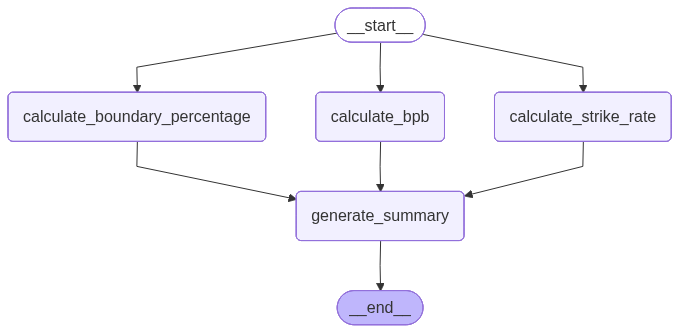

In [27]:
workflow

In [28]:
initial_state = {
    'runs' : 60,
    'balls' : 24,
    'fours' : 4,
    'sixes' : 4
}

In [31]:
final_state = workflow.invoke(initial_state)

In [32]:
final_state

{'runs': 60,
 'balls': 24,
 'fours': 4,
 'sixes': 4,
 'strike_rate': 250.0,
 'bpb': 10.0,
 'boundary_percentage': 66.66666666666666,
 'summary': '\n    Strike Rate: 250.0\n    Balls/Boundary: 10.0\n    Boundary Percentage: 66.66666666666666\n    '}